# Homework 1 - Part 3: Linear SVM Classifier
### Burak Kurucay - 210104004049
---

This section models a linear SVM classifier on the Breast Cancer Wisconsin dataset.
The model is evaluated with 6-fold cross validation using ROC curves, confusion matrices,
classification metrics, and runtime analysis.


## Code:

### Import the necessary modules

In [8]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


### Load the dataset
Load the data and show the number of samples, features, and class names.

In [9]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Feature count:", X.shape[1])
print("Classes:", list(data.target_names))


Dataset shape: (569, 30)
Feature count: 30
Classes: [np.str_('malignant'), np.str_('benign')]


### Monitor the data
Just to see the dataset loaded.

In [10]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Train By 6-Fold Cross Validation
For each fold, fit a linear SVM, compute ROC curves from the decision scores, and choose the
classification threshold from the training ROC curve using Youden's J statistic (`TPR - FPR`).

In [11]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)

fold_results = []
overall_start_time = time.time()

for fold_idx, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(random_state=42, dual="auto", max_iter=20000))
    ])

    fold_start_time = time.time()
    model.fit(X_train, y_train)

    train_scores = model.decision_function(X_train)
    test_scores = model.decision_function(X_test)
    fold_end_time = time.time()

    train_fpr, train_tpr, train_thresholds = roc_curve(y_train, train_scores)
    test_fpr, test_tpr, _ = roc_curve(y_test, test_scores)

    best_idx = np.argmax(train_tpr - train_fpr)
    best_threshold = train_thresholds[best_idx]

    train_predictions = (train_scores >= best_threshold).astype(int)
    test_predictions = (test_scores >= best_threshold).astype(int)

    fold_results.append({
        "fold": fold_idx,
        "threshold": best_threshold,
        "train_accuracy": accuracy_score(y_train, train_predictions),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "train_precision": precision_score(y_train, train_predictions, zero_division=0),
        "test_precision": precision_score(y_test, test_predictions, zero_division=0),
        "train_recall": recall_score(y_train, train_predictions, zero_division=0),
        "test_recall": recall_score(y_test, test_predictions, zero_division=0),
        "train_f1": f1_score(y_train, train_predictions, zero_division=0),
        "test_f1": f1_score(y_test, test_predictions, zero_division=0),
        "train_auc": roc_auc_score(y_train, train_scores),
        "test_auc": roc_auc_score(y_test, test_scores),
        "train_confusion_matrix": confusion_matrix(y_train, train_predictions),
        "test_confusion_matrix": confusion_matrix(y_test, test_predictions),
        "train_fpr": train_fpr,
        "train_tpr": train_tpr,
        "test_fpr": test_fpr,
        "test_tpr": test_tpr,
        "runtime_seconds": fold_end_time - fold_start_time
    })

overall_end_time = time.time()
mean_runtime = np.mean([r["runtime_seconds"] for r in fold_results])
total_runtime = overall_end_time - overall_start_time


## Results:

### Test Fold Confusion Matrices

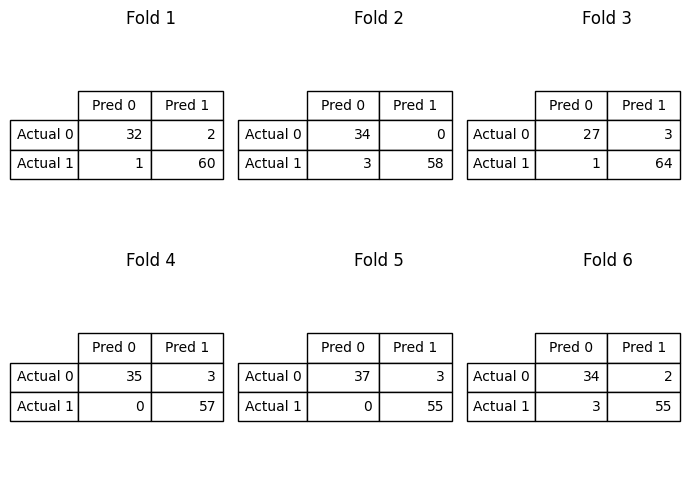

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax = axes[i]
    ax.axis("off")

    cm = result["test_confusion_matrix"]
    table_data = [
        [cm[0][0], cm[0][1]],
        [cm[1][0], cm[1][1]]
    ]

    table = ax.table(
        cellText=table_data,
        rowLabels=["Actual 0", "Actual 1"],
        colLabels=["Pred 0", "Pred 1"],
        loc="center"
    )
    table.scale(1, 1.5)
    ax.set_title(f"Fold {result['fold']}")

plt.tight_layout()
plt.show()


### Classification Metrics

,Fold,Threshold,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,1,-0.0123,0.9916,0.9684,0.9899,0.9677,0.9966,0.9836,0.9933,0.9756,0.9989,0.9957
1,2,0.1794,0.9895,0.9684,0.9899,1.0000,0.9932,0.9508,0.9916,0.9748,0.9988,0.9966
2,3,-0.2221,0.9916,0.9579,0.9865,0.9552,1.0000,0.9846,0.9932,0.9697,0.9987,0.9954
3,4,-0.0318,0.9937,0.9684,0.9901,0.9500,1.0000,1.0000,0.9950,0.9744,0.9996,0.9751
4,5,-0.0781,0.9916,0.9684,0.9869,0.9483,1.0000,1.0000,0.9934,0.9735,0.9987,0.9836
5,6,0.3726,0.9937,0.9468,0.9966,0.9649,0.9933,0.9483,0.9950,0.9565,0.9997,0.9852


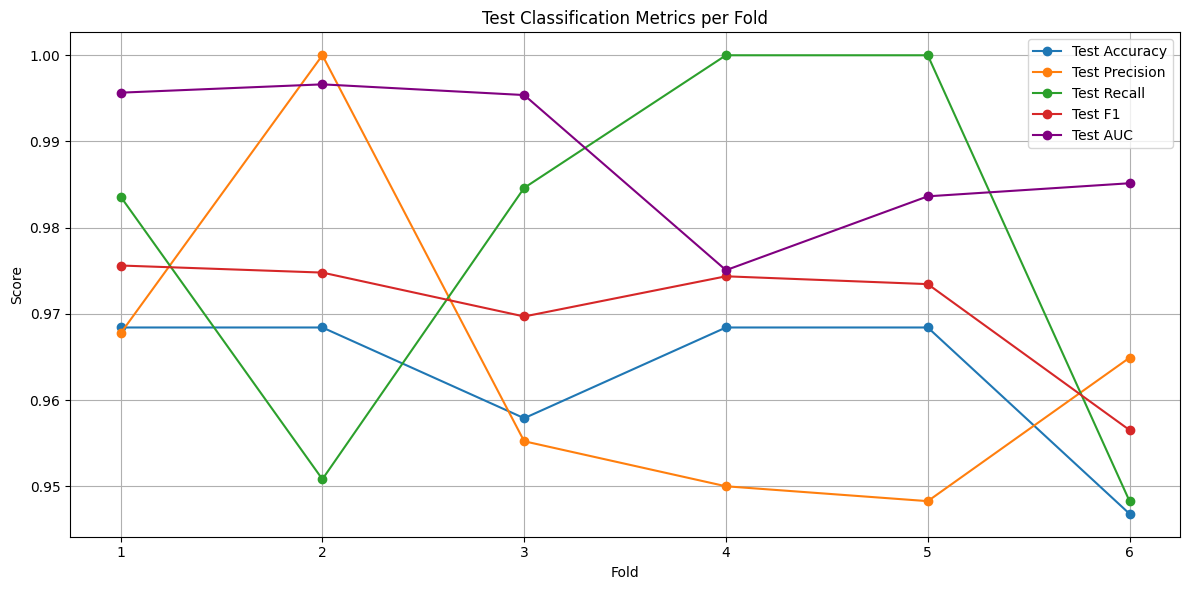

,Metric,Value
0,Mean Train Accuracy,0.9920
1,Mean Test Accuracy,0.9630
2,Mean Train Precision,0.9900
3,Mean Test Precision,0.9644
4,Mean Train Recall,0.9972
5,Mean Test Recall,0.9779
6,Mean Train F1,0.9936
7,Mean Test F1,0.9708
8,Mean Train AUC,0.9991
9,Mean Test AUC,0.9886


In [13]:
metric_rows = []

for result in fold_results:
    metric_rows.append({
        "Fold": result["fold"],
        "Threshold": result["threshold"],
        "Train Accuracy": result["train_accuracy"],
        "Test Accuracy": result["test_accuracy"],
        "Train Precision": result["train_precision"],
        "Test Precision": result["test_precision"],
        "Train Recall": result["train_recall"],
        "Test Recall": result["test_recall"],
        "Train F1": result["train_f1"],
        "Test F1": result["test_f1"],
        "Train AUC": result["train_auc"],
        "Test AUC": result["test_auc"]
    })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].round(4)
display(df_metrics)

folds = [r["fold"] for r in fold_results]
test_accuracies = [r["test_accuracy"] for r in fold_results]
test_precisions = [r["test_precision"] for r in fold_results]
test_recalls = [r["test_recall"] for r in fold_results]
test_f1s = [r["test_f1"] for r in fold_results]
test_aucs = [r["test_auc"] for r in fold_results]

plt.figure(figsize=(12, 6))
plt.plot(folds, test_accuracies, marker="o", label="Test Accuracy")
plt.plot(folds, test_precisions, marker="o", label="Test Precision")
plt.plot(folds, test_recalls, marker="o", label="Test Recall")
plt.plot(folds, test_f1s, marker="o", label="Test F1")
plt.plot(folds, test_aucs, marker="o", color="purple", label="Test AUC")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Test Classification Metrics per Fold")
plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

df_metrics_summary = pd.DataFrame({
    "Metric": [
        "Mean Train Accuracy",
        "Mean Test Accuracy",
        "Mean Train Precision",
        "Mean Test Precision",
        "Mean Train Recall",
        "Mean Test Recall",
        "Mean Train F1",
        "Mean Test F1",
        "Mean Train AUC",
        "Mean Test AUC"
    ],
    "Value": [
        df_metrics["Train Accuracy"].mean(),
        df_metrics["Test Accuracy"].mean(),
        df_metrics["Train Precision"].mean(),
        df_metrics["Test Precision"].mean(),
        df_metrics["Train Recall"].mean(),
        df_metrics["Test Recall"].mean(),
        df_metrics["Train F1"].mean(),
        df_metrics["Test F1"].mean(),
        df_metrics["Train AUC"].mean(),
        df_metrics["Test AUC"].mean()
    ]
})

df_metrics_summary["Value"] = df_metrics_summary["Value"].round(4)
display(df_metrics_summary)


### Runtime Performance
The runtime of the linear SVM classifier was measured for each fold during the 6-fold cross validation process.  
Both per-fold runtimes and the total cross-validation runtime are reported below.

In [14]:
runtime_rows = []

for result in fold_results:
    runtime_rows.append({
        "Fold": result["fold"],
        "Runtime (seconds)": result["runtime_seconds"]
    })

df_runtime = pd.DataFrame(runtime_rows)
df_runtime["Runtime (seconds)"] = df_runtime["Runtime (seconds)"].round(4)
display(df_runtime)

df_runtime_summary = pd.DataFrame({
    "Metric": [
        "Average runtime per fold",
        "Total 6-fold CV runtime"
    ],
    "Runtime (seconds)": [
        mean_runtime,
        total_runtime
    ]
})

df_runtime_summary["Runtime (seconds)"] = df_runtime_summary["Runtime (seconds)"].round(4)
display(df_runtime_summary)


,Fold,Runtime (seconds)
0,1,0.0052
1,2,0.0020
2,3,0.0014
3,4,0.0015
4,5,0.0015
5,6,0.0016


,Metric,Runtime (seconds)
0,Average runtime per fold,0.0022
1,Total 6-fold CV runtime,0.0532


### Selected Fold Performance Results
Select the fold whose test AUC is closest to the mean test AUC across all folds.

In [15]:
mean_test_auc = np.mean([r["test_auc"] for r in fold_results])

selected_fold = min(
    fold_results,
    key=lambda r: abs(r["test_auc"] - mean_test_auc)
)


,Metric,Value
0,Threshold,0.3726
1,Train Accuracy,0.9937
2,Test Accuracy,0.9468
3,Train Precision,0.9966
4,Test Precision,0.9649
5,Train Recall,0.9933
6,Test Recall,0.9483
7,Train F1,0.9950
8,Test F1,0.9565
9,Train AUC,0.9997


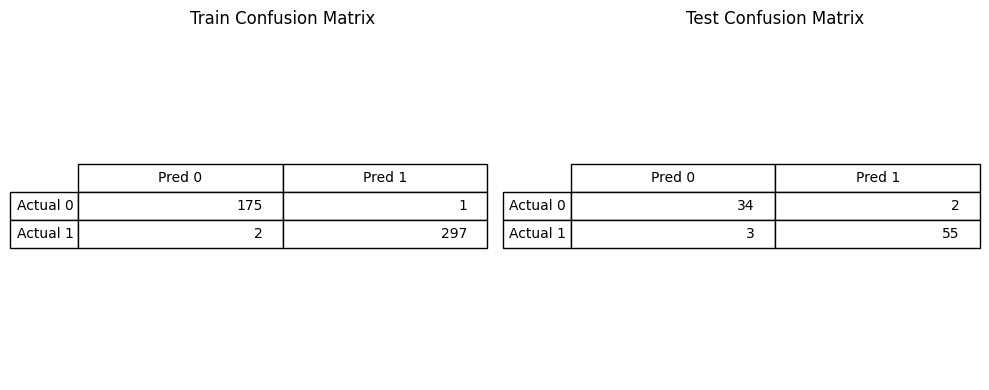

In [16]:
df_selected_performance = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Train Accuracy", "Test Accuracy",
        "Train Precision", "Test Precision",
        "Train Recall", "Test Recall",
        "Train F1", "Test F1",
        "Train AUC", "Test AUC"
    ],
    "Value": [
        selected_fold["threshold"],
        selected_fold["train_accuracy"], selected_fold["test_accuracy"],
        selected_fold["train_precision"], selected_fold["test_precision"],
        selected_fold["train_recall"], selected_fold["test_recall"],
        selected_fold["train_f1"], selected_fold["test_f1"],
        selected_fold["train_auc"], selected_fold["test_auc"]
    ]
})

df_selected_performance["Value"] = df_selected_performance["Value"].round(4)
display(df_selected_performance)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, matrix_key, title in [
    (axes[0], "train_confusion_matrix", "Train Confusion Matrix"),
    (axes[1], "test_confusion_matrix", "Test Confusion Matrix")
]:
    ax.axis("off")
    cm = selected_fold[matrix_key]
    table = ax.table(
        cellText=[[cm[0][0], cm[0][1]], [cm[1][0], cm[1][1]]],
        rowLabels=["Actual 0", "Actual 1"],
        colLabels=["Pred 0", "Pred 1"],
        loc="center"
    )
    table.scale(1, 1.5)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Selected Fold ROC Curve
ROC is drawn only for the selected fold. The SVM does not output probabilities here, so the curve is computed from `decision_function` scores. We sweep the threshold over these scores and plot TPR against FPR.

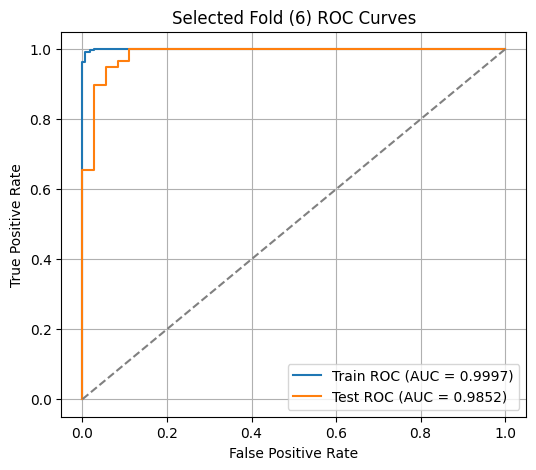

In [17]:
plt.figure(figsize=(6, 5))
plt.plot(
    selected_fold["train_fpr"],
    selected_fold["train_tpr"],
    label=f"Train ROC (AUC = {selected_fold['train_auc']:.4f})"
)
plt.plot(
    selected_fold["test_fpr"],
    selected_fold["test_tpr"],
    label=f"Test ROC (AUC = {selected_fold['test_auc']:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Selected Fold ({selected_fold['fold']}) ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

## Comments:
- The linear SVM produces very stable results across folds. Test accuracy, test F1, and test AUC vary only within a narrow interval, which suggests that the learned separating hyperplane is robust under different train-test splits.
- Training metrics are slightly higher than test metrics, but the gap remains limited. This indicates that the model fits the training data well without showing a strong sign of overfitting.
- The threshold values change from fold to fold because they are selected from the training data by using Youden's J statistic. This is an expected outcome, since the scale of the decision scores may shift even when the overall classification quality stays similar.
- Test AUC stays consistently high, which means that the decision scores preserve class ranking effectively. For SVM, this is an important observation because the model naturally outputs margins rather than calibrated probabilities.
- Compared with KNN, the runtime is much lower. This is also expected, because once the linear decision function is learned, prediction becomes computationally simple.
